In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [3]:
# 1. setting paths

data_dir = "../data/ddi"                  
images_dir = os.path.join(data_dir, "images")
metadata_path = os.path.join(data_dir, "ddi_metadata.csv")

print(f"Images folder exists: {os.path.exists(images_dir)}")
print(f"Number of images: {len([f for f in os.listdir(images_dir) if f.endswith('.png')])}")
print(f"Metadata exists: {os.path.exists(metadata_path)}")

Images folder exists: True
Number of images: 656
Metadata exists: True


In [4]:
# 2. load metadata

df = pd.read_csv(metadata_path)
print(f"\nMetadata shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

print("\nColumns:", df.columns.tolist())

# Drop useless 'Unnamed: 0' if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])


Metadata shape: (656, 6)

First 5 rows:


,Unnamed: 0,DDI_ID,DDI_file,skin_tone,malignant,disease
0,0,1,000001.png,56,True,melanoma-in-situ
1,1,2,000002.png,56,True,melanoma-in-situ
2,2,3,000003.png,56,True,mycosis-fungoides
3,3,4,000004.png,56,True,squamous-cell-carcinoma-in-situ
4,4,5,000005.png,12,True,basal-cell-carcinoma



Columns: ['Unnamed: 0', 'DDI_ID', 'DDI_file', 'skin_tone', 'malignant', 'disease']


In [5]:
label_col = 'disease'
malignant_col = 'malignant'

print("\nDisease distribution:")
print(df[label_col].value_counts())

print("\nMalignant distribution:")
print(df[malignant_col].value_counts(normalize=True))


Disease distribution:
disease
melanocytic-nevi             119
seborrheic-keratosis          58
verruca-vulgaris              50
basal-cell-carcinoma          41
epidermal-cyst                35
                            ... 
keloid                         1
angioleiomyoma                 1
lymphocytic-infiltrations      1
wart                           1
acral-melanotic-macule         1
Name: count, Length: 78, dtype: int64

Malignant distribution:
malignant
False    0.739329
True     0.260671
Name: proportion, dtype: float64


C:\Users\Sharon\AppData\Local\Temp\ipykernel_27696\1451803994.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=label_col, order=df[label_col].value_counts().index, palette='viridis')


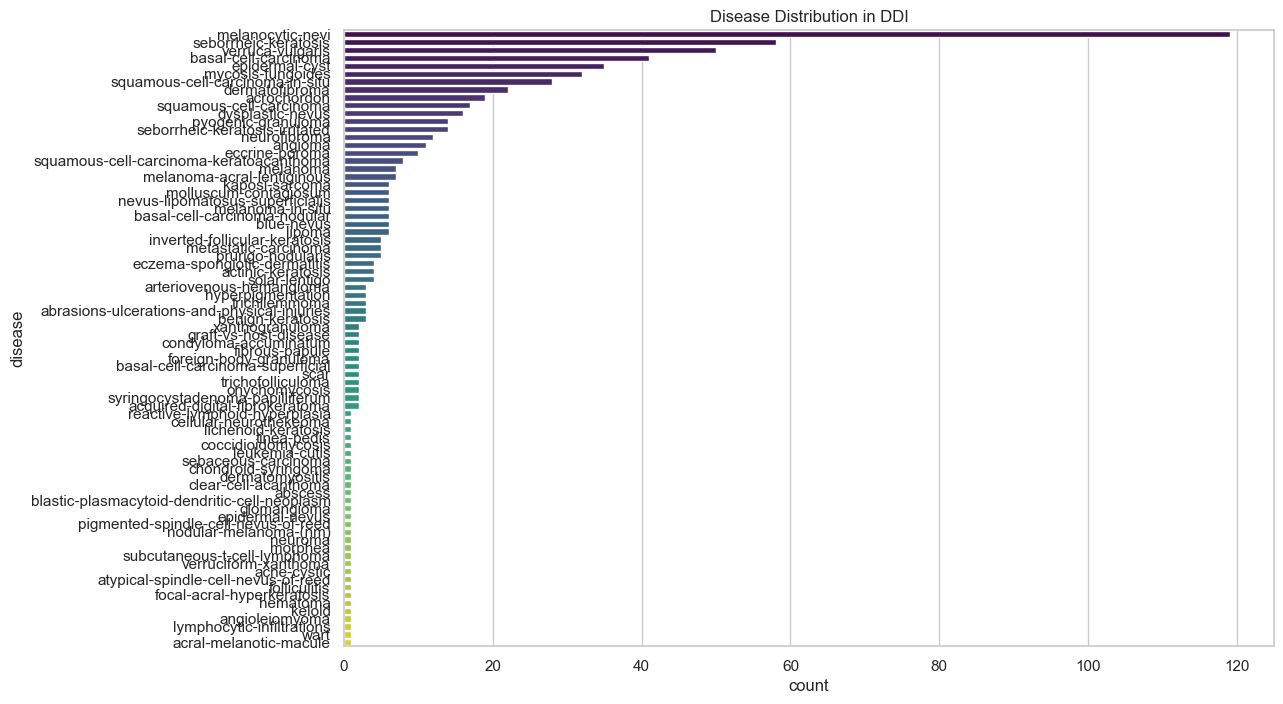

C:\Users\Sharon\AppData\Local\Temp\ipykernel_27696\1451803994.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=df[malignant_col].astype(str), palette='Set1')


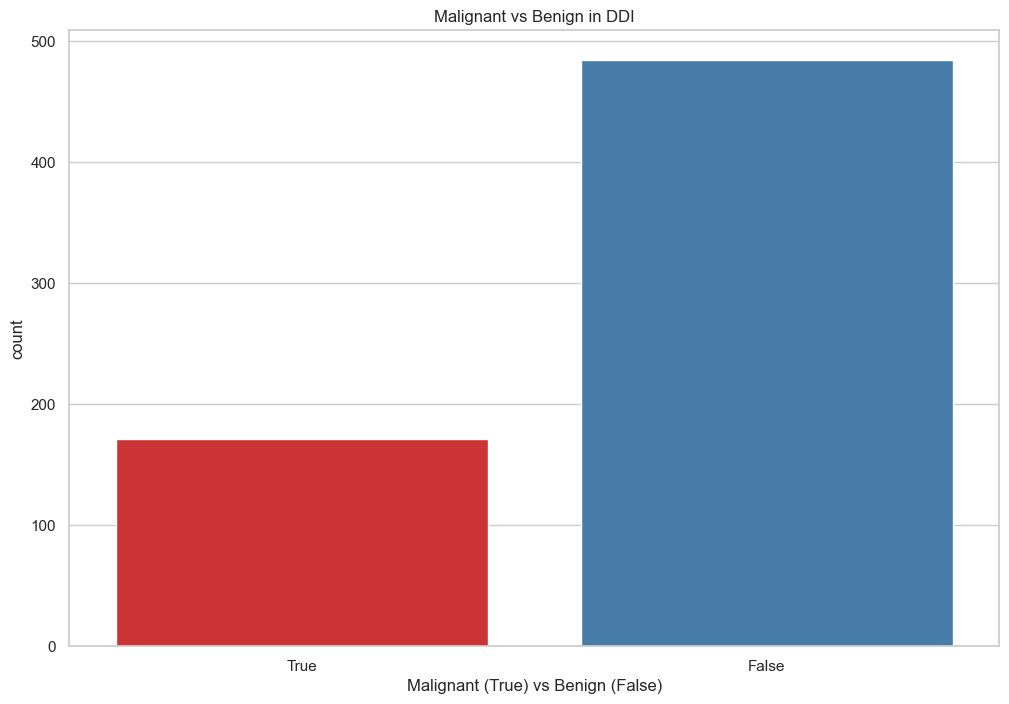

In [6]:
plt.figure()
sns.countplot(data=df, y=label_col, order=df[label_col].value_counts().index, palette='viridis')
plt.title("Disease Distribution in DDI")
plt.show()

plt.figure()
sns.countplot(data=df, x=df[malignant_col].astype(str), palette='Set1')
plt.title("Malignant vs Benign in DDI")
plt.xlabel("Malignant (True) vs Benign (False)")
plt.show()

C:\Users\Sharon\AppData\Local\Temp\ipykernel_27696\1097730904.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(



Skin Tone distribution:
skin_tone
12    208
34    241
56    207
Name: count, dtype: int64


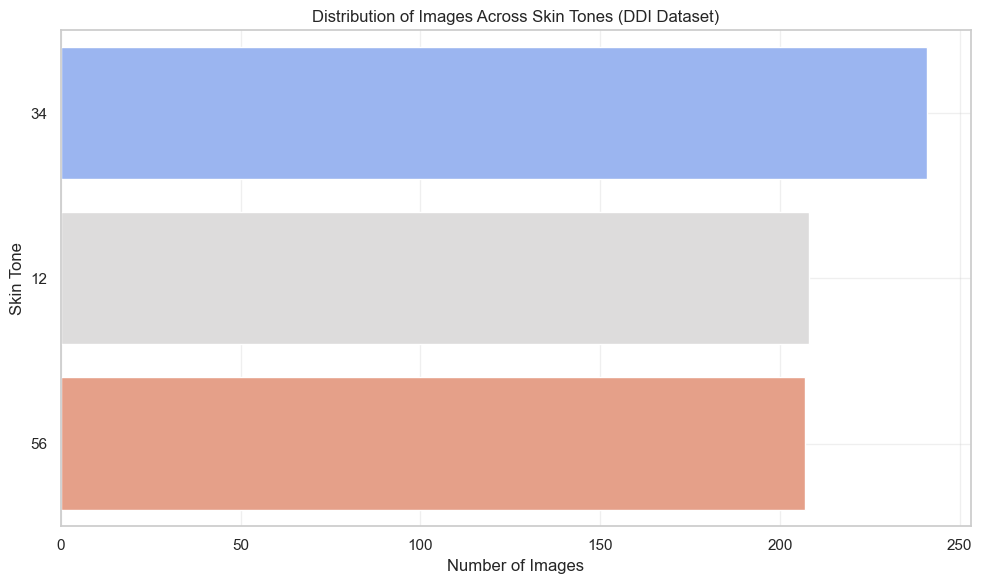

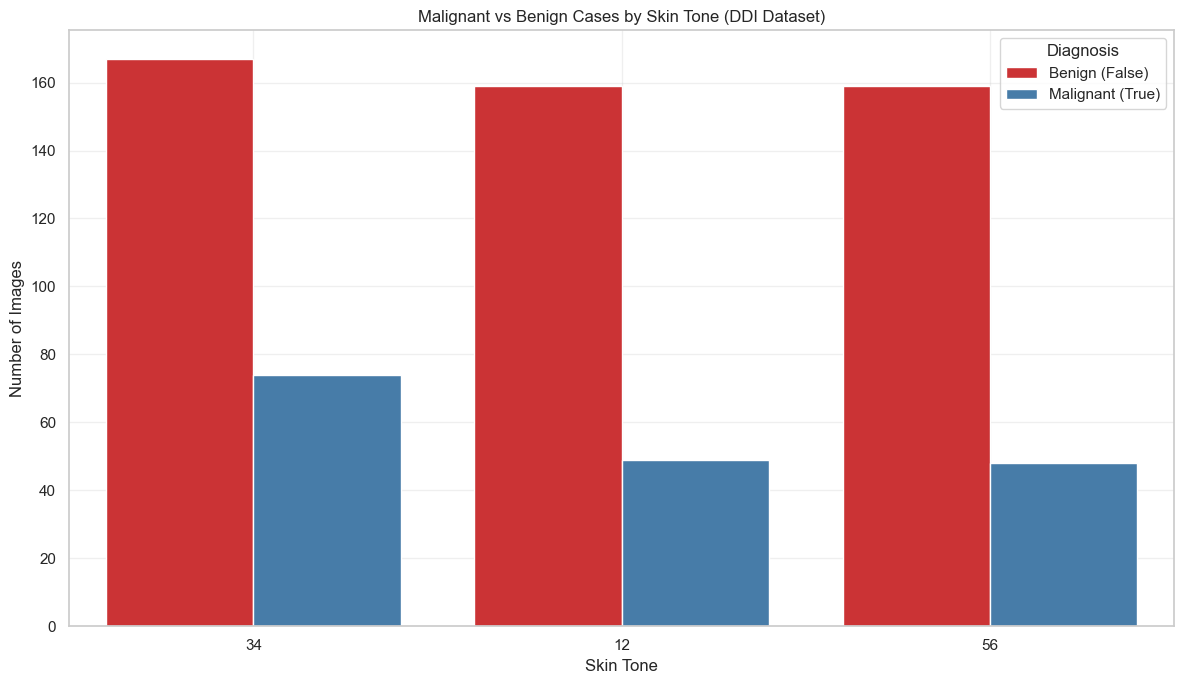

In [7]:
skin_tone_col = 'skin_tone'
malignant_col = 'malignant'

# Print distribution for reference
print("\nSkin Tone distribution:")
print(df[skin_tone_col].value_counts().sort_index())

# Plot 1: Count of images per skin tone (horizontal for better readability)
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    y=df[skin_tone_col].astype(str),
    order=df[skin_tone_col].value_counts().index.astype(str),
    palette='coolwarm'
)
plt.title("Distribution of Images Across Skin Tones (DDI Dataset)")
plt.xlabel("Number of Images")
plt.ylabel("Skin Tone")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Plot 2: Malignant vs Benign breakdown per skin tone (key bias insight)
plt.figure(figsize=(12, 7))
sns.countplot(
    data=df,
    x=df[skin_tone_col].astype(str),
    hue=df[malignant_col].astype(str),
    palette='Set1',
    order=df[skin_tone_col].value_counts().index.astype(str),
    hue_order=['False', 'True']
)
plt.title("Malignant vs Benign Cases by Skin Tone (DDI Dataset)")
plt.xlabel("Skin Tone")
plt.ylabel("Number of Images")
plt.legend(
    title="Diagnosis",
    labels=['Benign (False)', 'Malignant (True)'],
    loc='upper right'
)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

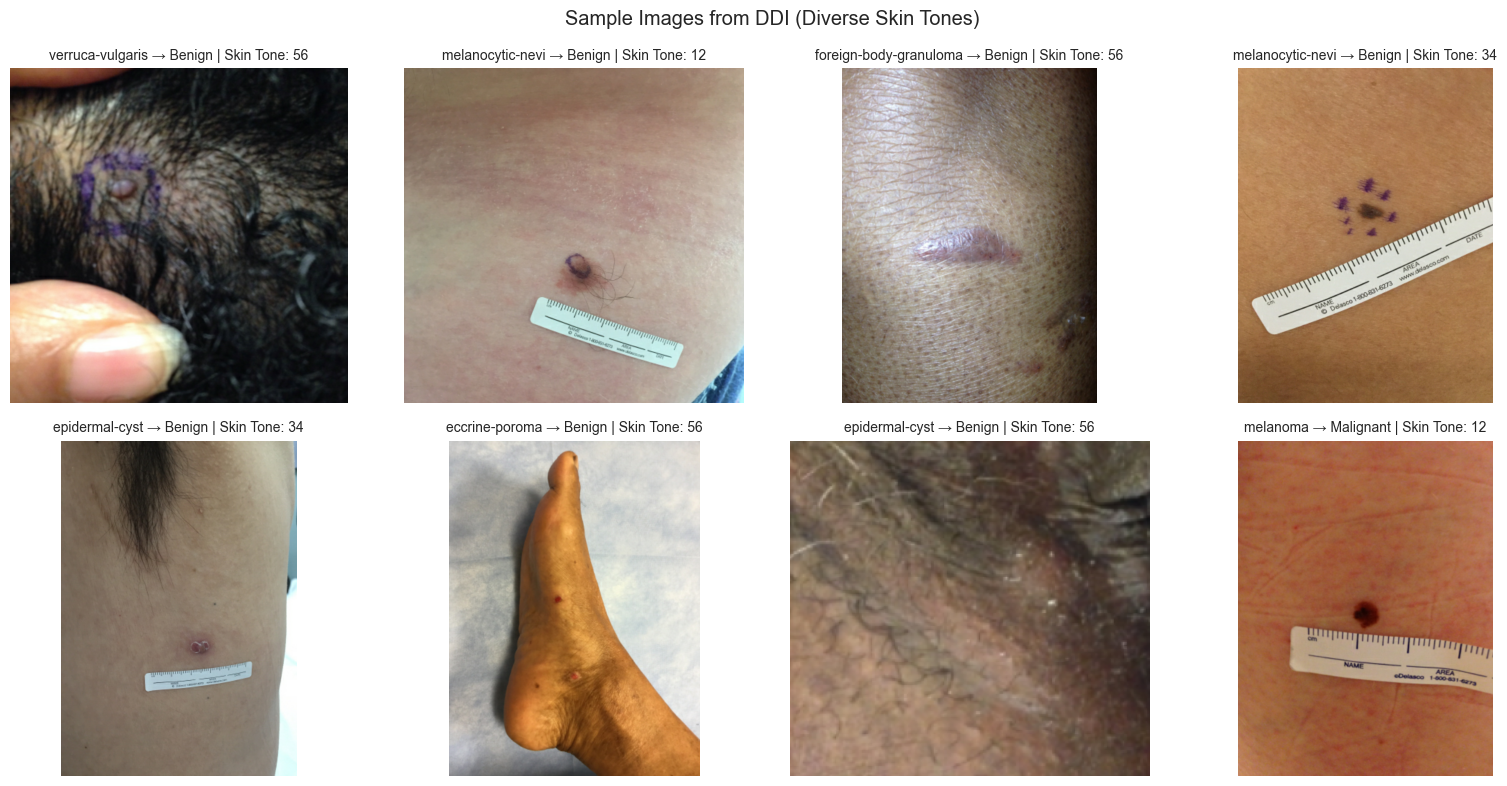

In [8]:
# 5. sample images

def show_samples(df, n=8, seed=42):
    sample_df = df.sample(n=n, random_state=seed)
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.ravel()
    
    for idx, row in enumerate(sample_df.itertuples()):
        img_filename = getattr(row, 'DDI_file')  # Already has .png
        img_path = os.path.join(images_dir, img_filename)
        
        if not os.path.exists(img_path):
            print(f"Warning: Missing → {img_path}")
            axes[idx].text(0.5, 0.5, "Missing", ha='center', va='center')
            axes[idx].axis('off')
            continue
        
        img = Image.open(img_path)
        axes[idx].imshow(img)
        
        title = f"{getattr(row, label_col)} → {'Malignant' if getattr(row, malignant_col) else 'Benign'}"
        if skin_tone_col in df.columns:
            title += f" | Skin Tone: {getattr(row, skin_tone_col)}"
        
        axes[idx].set_title(title, fontsize=10)
        axes[idx].axis('off')
    
    plt.suptitle("Sample Images from DDI (Diverse Skin Tones)")
    plt.tight_layout()
    plt.show()

show_samples(df, n=8)